# BigData benchmark 




В этом ноутбуке представлены результаты сравнения разных форматов хранения данных и инструментов обработки данных.

В работе сравниваются CSV, Parquet и SQLite для чтения и выполнения SQL-запросов, а также несколько библиотек для обработки JSON / JSONL.

- времени записи данных;
- размеру файлов;
- времени полного чтения;
- времени выполнения SQL-запросов;
- сравнению результатов для разных форматов и библиотек.

In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 90)

print(ROOT)


c:\Users\21214\Desktop\bigdata_submit


## 1. Расположение файлов

In [5]:
items = [
    "download_wet_until_target.py",
    "build_large_formats_from_wet.py",
    "benchmark_write_formats.py",
    "benchmark_formats.py",
    "benchmark_libs.py",
    "benchmark_large_formats.py",
    "data_formats/csv/docs.csv",
    "data_formats/parquet/docs.parquet",
    "data_formats/sqlite/docs.db",
    "benchmarks/write_benchmark_results.csv",
    "benchmarks/benchmark_results.csv",
    "benchmarks/library_compare_results.csv",
    "benchmarks_large/benchmark_large_results.csv",
]

rows = []
for name in items:
    p = ROOT / name
    rows.append({
        "path": name,
        "exists": p.exists(),
        "size_mb": round(p.stat().st_size / 1024**2, 2) if p.exists() and p.is_file() else None,
    })

check = pd.DataFrame(rows)
display(check)


,path,exists,size_mb
0,download_wet_until_target.py,True,0.00
1,build_large_formats_from_wet.py,True,0.01
2,benchmark_write_formats.py,True,0.00
3,benchmark_formats.py,True,0.01
4,benchmark_libs.py,True,0.01
5,benchmark_large_formats.py,True,0.01
6,data_formats/csv/docs.csv,True,165.46
7,data_formats/parquet/docs.parquet,True,59.30
8,data_formats/sqlite/docs.db,True,179.06
9,benchmarks/write_benchmark_results.csv,True,0.00


## 2. Загрузка таблиц с результатами

In [6]:
write = pd.read_csv(ROOT / "benchmarks/write_benchmark_results.csv")
bench = pd.read_csv(ROOT / "benchmarks/benchmark_results.csv")
libs = pd.read_csv(ROOT / "benchmarks/library_compare_results.csv")

print("write:", write.shape)
print("bench:", bench.shape)
print("libs:", libs.shape)


write: (7, 10)
bench: (15, 11)
libs: (11, 10)


## 3. Тест записи

,format,engine,wall_time_avg_sec,cpu_time_avg_sec,file_size_mb
2,csv,polars,0.079969,0.286458,165.46
3,tsv,polars,0.088053,0.130208,165.46
5,orc,pyarrow,0.669482,0.645833,165.13
0,json,stdlib_json,0.963052,0.958333,170.87
1,jsonl,stdlib_json,1.037107,1.026042,170.87
6,sqlite,pandas+sqlalchemy,1.319980,0.708333,177.85
4,parquet,polars,1.410483,1.406250,59.30


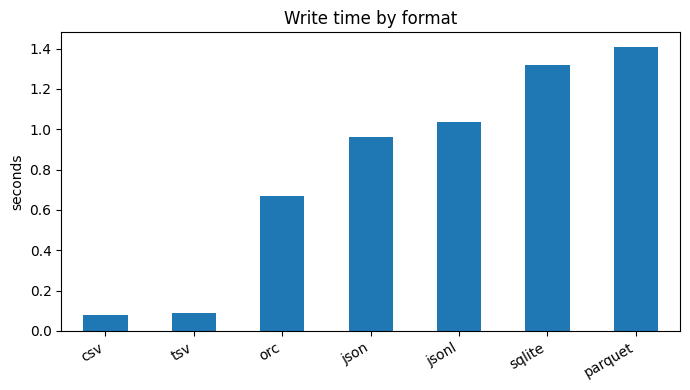

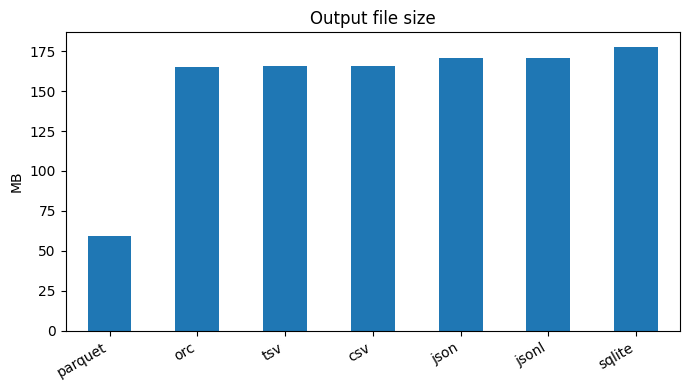

In [7]:
write_cols = ["format", "engine", "wall_time_avg_sec", "cpu_time_avg_sec", "file_size_mb"]
display(write[write_cols].sort_values("wall_time_avg_sec"))

ax = write.sort_values("wall_time_avg_sec").plot(
    x="format", y="wall_time_avg_sec", kind="bar", legend=False, figsize=(7, 4)
)
ax.set_title("Write time by format")
ax.set_xlabel("")
ax.set_ylabel("seconds")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

ax = write.sort_values("file_size_mb").plot(
    x="format", y="file_size_mb", kind="bar", legend=False, figsize=(7, 4)
)
ax.set_title("Output file size")
ax.set_xlabel("")
ax.set_ylabel("MB")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Анализ результатов записи

По времени записи лучше всего показали себя CSV и TSV. Это ожидаемый результат: оба формата устроены достаточно просто, поэтому данные записываются без сложной дополнительной обработки.

Parquet записывался дольше, но при этом дал самый компактный файл. В моём тесте его размер составил около 59 MB, тогда как CSV занял примерно 165 MB. Поэтому, если важен не только сам процесс записи, но и дальнейшее хранение и анализ данных, Parquet выглядит более подходящим вариантом.

SQLite оказался медленнее CSV и TSV при записи. Однако его преимущество в другом: данные сразу сохраняются в структурированном виде, и с ними можно работать через SQL без отдельного преобразования файла.

## 4.  Описание SQL-запросов

В ноутбуке используются три запроса: фильтрация, группировка и оконная функция. Я выбрал их потому, что они проверяют разные типы работы с данными: простой отбор строк, агрегирование и более сложную аналитическую операцию.

### Query 1. Фильтрация данных

В первом запросе выбираются документы с указанным доменом и длиной текста больше 1000 символов. Такой запрос показывает, насколько быстро формат или библиотека справляется с обычной фильтрацией.

```sql
SELECT COUNT(*) AS matched_rows,
       AVG(text_len) AS avg_text_len
FROM docs
WHERE domain <> ''
  AND text_len > 1000;
```

### Query 2. Группировка по доменам

Во втором запросе данные группируются по доменам. Для каждого домена считается количество документов и средняя длина текста. Этот вариант нужен для проверки агрегирующих операций.

```sql
SELECT domain,
       COUNT(*) AS doc_cnt,
       AVG(text_len) AS avg_text_len
FROM docs
WHERE domain <> ''
GROUP BY domain
ORDER BY doc_cnt DESC, domain
LIMIT 20;
```

### Query 3. Оконная функция

Третий запрос использует `ROW_NUMBER()`. Внутри каждого домена строки упорядочиваются по дате, после чего им присваивается номер. Такой запрос позволяет посмотреть, как разные инструменты работают с оконными функциями.

```sql
SELECT domain, warc_date, text_len,
       ROW_NUMBER() OVER (
           PARTITION BY domain
           ORDER BY warc_date
       ) AS rn
FROM docs
WHERE domain <> ''
LIMIT 50;
```

## 5. Чтение и выполнение запросов

In [8]:
size_rows = bench[bench["category"] == "file_size"][["format", "result_info"]]
read_rows = bench[bench["category"] == "read"][["format", "engine", "task", "wall_time_avg_sec", "result_info"]]
query_rows = bench[bench["category"] == "query"][["format", "engine", "task", "wall_time_avg_sec", "result_info"]]

display(size_rows)
display(read_rows.sort_values("wall_time_avg_sec"))
display(query_rows.sort_values(["task", "wall_time_avg_sec"]))


,format,result_info
0,csv,165.46 MB
1,parquet,59.30 MB
2,sqlite,179.06 MB


,format,engine,task,wall_time_avg_sec,result_info
3,csv,polars,full_read,0.074635,"rows=19637, cols=8"
4,parquet,polars,full_read,0.199754,"rows=19637, cols=8"
5,sqlite,pandas+sqlite3,full_read,0.438260,"rows=19637, cols=8"


,format,engine,task,wall_time_avg_sec,result_info
9,parquet,duckdb,filter,0.015185,"{'matched_rows': 16709, 'avg_text_len': 7996.7655155904}"
12,sqlite,sqlite3,filter,0.069107,"{'matched_rows': 16709, 'avg_text_len': 7996.7655155904}"
6,csv,duckdb,filter,1.250770,"{'matched_rows': 16709, 'avg_text_len': 7996.7655155904}"
10,parquet,duckdb,group_by,0.017706,rows=20
13,sqlite,sqlite3,group_by,0.115584,rows=20
7,csv,duckdb,group_by,0.538809,rows=20
11,parquet,duckdb,window,0.019256,"{'n_rows': 19637, 'max_rn': 12}"
14,sqlite,sqlite3,window,0.071817,"{'n_rows': 19637, 'max_rn': 12}"
8,csv,duckdb,window,0.571023,"{'n_rows': 19637, 'max_rn': 12}"


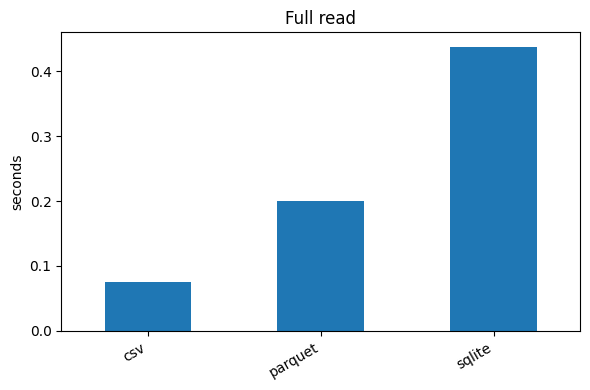

format,csv,parquet,sqlite
task,,,
filter,1.250770,0.015185,0.069107
group_by,0.538809,0.017706,0.115584
window,0.571023,0.019256,0.071817


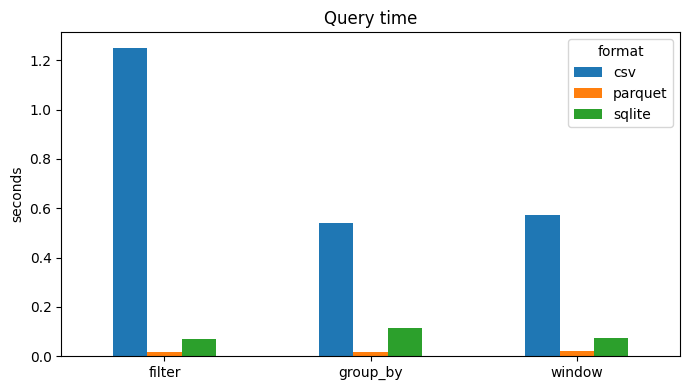

In [9]:
ax = read_rows.sort_values("wall_time_avg_sec").plot(
    x="format", y="wall_time_avg_sec", kind="bar", legend=False, figsize=(6, 4)
)
ax.set_title("Full read")
ax.set_xlabel("")
ax.set_ylabel("seconds")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

query_pivot = query_rows.pivot(index="task", columns="format", values="wall_time_avg_sec")
display(query_pivot)

ax = query_pivot.plot(kind="bar", figsize=(7, 4))
ax.set_title("Query time")
ax.set_xlabel("")
ax.set_ylabel("seconds")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Анализ времени выполнения запросов

По таблице и графику видно, что во всех трёх запросах быстрее всего сработал вариант Parquet через DuckDB. Разница особенно заметна в запросе filter: для Parquet время получилось около 0.015 секунды, а для CSV через DuckDB — примерно 1.25 секунды.

Такой результат логичен, потому что Parquet хранит данные по колонкам и лучше подходит для аналитических запросов. CSV, наоборот, является текстовым форматом, поэтому при каждом запросе данные нужно заново читать и разбирать.

SQLite показал более ровный результат, чем CSV, но всё равно уступил DuckDB + Parquet. Поэтому в этой работе SQLite можно рассматривать как удобный вариант для локального хранения и простых SQL-запросов, а Parquet вместе с DuckDB — как более эффективный вариант для аналитики.

In [10]:
query_time_table = query_rows[[
    "task", "format", "engine", "wall_time_avg_sec", "result_info"
]].sort_values(["task", "wall_time_avg_sec"])

display(query_time_table)

query_compare = query_rows.pivot_table(
    index="task",
    columns="format",
    values="wall_time_avg_sec",
    aggfunc="mean"
).reset_index()

query_compare["csv_vs_parquet_times"] = query_compare["csv"] / query_compare["parquet"]
query_compare["sqlite_vs_parquet_times"] = query_compare["sqlite"] / query_compare["parquet"]

display(query_compare)

,task,format,engine,wall_time_avg_sec,result_info
9,filter,parquet,duckdb,0.015185,"{'matched_rows': 16709, 'avg_text_len': 7996.7655155904}"
12,filter,sqlite,sqlite3,0.069107,"{'matched_rows': 16709, 'avg_text_len': 7996.7655155904}"
6,filter,csv,duckdb,1.250770,"{'matched_rows': 16709, 'avg_text_len': 7996.7655155904}"
10,group_by,parquet,duckdb,0.017706,rows=20
13,group_by,sqlite,sqlite3,0.115584,rows=20
7,group_by,csv,duckdb,0.538809,rows=20
11,window,parquet,duckdb,0.019256,"{'n_rows': 19637, 'max_rn': 12}"
14,window,sqlite,sqlite3,0.071817,"{'n_rows': 19637, 'max_rn': 12}"
8,window,csv,duckdb,0.571023,"{'n_rows': 19637, 'max_rn': 12}"


format,task,csv,parquet,sqlite,csv_vs_parquet_times,sqlite_vs_parquet_times
0,filter,1.250770,0.015185,0.069107,82.371109,4.551141
1,group_by,0.538809,0.017706,0.115584,30.431344,6.528036
2,window,0.571023,0.019256,0.071817,29.654443,3.729598


## 7. Обработка JSON / JSONL

,category,engine,task,wall_time_avg_sec,cpu_time_avg_sec,result_info
1,json,orjson,dumps_array,0.015872,0.015625,29482026
2,json,ujson,dumps_array,0.092970,0.093750,18020189
0,json,stdlib,dumps_array,0.122352,0.125000,18002913
3,json,stdlib,loads_array,0.045500,0.046875,2000
4,json,orjson,loads_array,0.057553,0.057292,2000
5,json,ujson,loads_array,0.075016,0.078125,2000
6,jsonl,stdlib,parse_sample_lines,0.033818,0.031250,2000
8,jsonl,ujson,parse_sample_lines,0.063832,0.062500,2000
7,jsonl,orjson,parse_sample_lines,0.071808,0.078125,2000
10,rawpython,multiprocessing,full_scan_multi_process,1.636777,1.046875,"{'rows': 19637, 'matched_rows': 16709, 'avg_text_len': 7996.7655155904}"


engine,orjson,stdlib,ujson
task,,,
dumps_array,0.015872,0.122352,0.092970
loads_array,0.057553,0.045500,0.075016
parse_sample_lines,0.071808,0.033818,0.063832


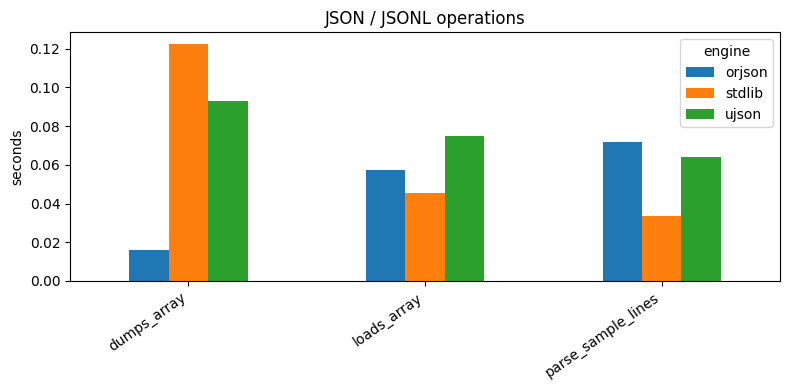

,engine,task,wall_time_avg_sec,result_info
9,stdlib_json,full_scan_single_process,0.685825,"{'rows': 19637, 'matched_rows': 16709, 'avg_text_len': 7996.7655155904}"
10,multiprocessing,full_scan_multi_process,1.636777,"{'rows': 19637, 'matched_rows': 16709, 'avg_text_len': 7996.7655155904}"


In [11]:
lib_cols = ["category", "engine", "task", "wall_time_avg_sec", "cpu_time_avg_sec", "result_info"]
display(libs[lib_cols].sort_values(["category", "task", "wall_time_avg_sec"]))

json_tasks = libs[libs["category"].isin(["json", "jsonl"])]
json_pivot = json_tasks.pivot_table(index="task", columns="engine", values="wall_time_avg_sec", aggfunc="mean")
display(json_pivot)

ax = json_pivot.plot(kind="bar", figsize=(8, 4))
ax.set_title("JSON / JSONL operations")
ax.set_xlabel("")
ax.set_ylabel("seconds")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

raw = libs[libs["category"] == "rawpython"][["engine", "task", "wall_time_avg_sec", "result_info"]]
display(raw)


### Анализ JSON / JSONL

Сравнение JSON-библиотек показывает, что `orjson` быстрее всего выполнил операцию сериализации массива (`dumps_array`). Однако при чтении и разборе JSONL стандартная библиотека `json` показала сопоставимый результат.

Multiprocessing в данном тесте не дал ускорения. Это может быть связано с тем, что объём данных в тестовом фрагменте недостаточно большой, а запуск нескольких процессов создаёт дополнительные накладные расходы.

## 8. Результаты запросов

In [12]:
preview_dir = ROOT / "benchmarks" / "query_outputs"

if preview_dir.exists():
    preview_files = sorted(preview_dir.glob("*.csv"))
    print("preview files:", len(preview_files))

    for fmt in ["csv", "parquet", "sqlite"]:
        print(f"\n===== {fmt.upper()} =====")

        files_for_format = [
            p for p in preview_files
            if p.name.startswith(fmt)
        ]

        for p in files_for_format:
            print("\n", p.name)
            display(pd.read_csv(p).head(5))
else:
    print("No query_outputs directory")

preview files: 9

===== CSV =====

 csv_filter_preview.csv


,doc_id,domain,warc_date,text_len
0,CC-MAIN-20260305070756-20260305100756-00000.warc.wet_2,020bld.cn.vauofnj.cn,2026-03-05 11:39:38+03:00,1598
1,CC-MAIN-20260305070756-20260305100756-00000.warc.wet_3,021sakura.com,2026-03-05 11:30:24+03:00,1065
2,CC-MAIN-20260305070756-20260305100756-00000.warc.wet_6,0553njl.com,2026-03-05 11:13:48+03:00,1464
3,CC-MAIN-20260305070756-20260305100756-00000.warc.wet_7,07921.cn,2026-03-05 10:36:34+03:00,4903
4,CC-MAIN-20260305070756-20260305100756-00000.warc.wet_8,07921.cn,2026-03-05 11:24:49+03:00,4708



 csv_group_preview.csv


,domain,doc_cnt,avg_text_len
0,americanindian.si.edu,12,45419.916667
1,librarysearch.royalholloway.ac.uk,9,44.000000
2,endicott.noblenet.org,8,1421.750000
3,news.qq.com,8,299.625000
4,www.shorenewsnetwork.com,7,2974.428571



 csv_window_preview.csv


...

,doc_id,domain,warc_date,text_len
0,CC-MAIN-20260305070756-20260305100756-00000.warc.wet_277,fidelissoftwaresolutions.com,2026-03-05T08:01:50Z,1001
1,CC-MAIN-20260305070756-20260305100756-00000.warc.wet_329,globalvv.com,2026-03-05T08:52:17Z,1001
2,CC-MAIN-20260305070756-20260305100756-00000.warc.wet_367,horinao.com,2026-03-05T08:02:29Z,1001
3,CC-MAIN-20260305070756-20260305100756-00000.warc.wet_11597,uto-knit.com,2026-03-05T07:36:25Z,1001
4,CC-MAIN-20260305070756-20260305100756-00000.warc.wet_12376,www.alkidprof.ru,2026-03-05T07:27:20Z,1001



 sqlite_group_preview.csv


,domain,doc_cnt,avg_text_len
0,americanindian.si.edu,12,45419.916667
1,librarysearch.royalholloway.ac.uk,9,44.000000
2,endicott.noblenet.org,8,1421.750000
3,news.qq.com,8,299.625000
4,www.shorenewsnetwork.com,7,2974.428571



 sqlite_window_preview.csv


,domain,warc_date,text_len,rn
0,020bld.cn.vauofnj.cn,2026-03-05T08:39:38Z,1598,1
1,021sakura.com,2026-03-05T08:30:24Z,1065,1
2,0225.ru,2026-03-05T07:37:08Z,7933,1
3,025.teny.co.jp,2026-03-05T08:51:40Z,1212,1
4,044mm.com,2026-03-05T08:54:07Z,765,1


Так как во всех вариантах используется один и тот же набор данных, результаты запросов для CSV, Parquet и SQLite должны совпадать по смыслу.

Главное отличие здесь не в самих полученных строках, а во времени выполнения. Поэтому в этом разделе я сравниваю не содержание результата, а то, насколько быстро разные форматы и инструменты выполняют одинаковые запросы.

## 9. Краткое описание результатов


In [13]:
fast_write = write.loc[write["wall_time_avg_sec"].idxmin()]
small_file = write.loc[write["file_size_mb"].idxmin()]
fast_read = read_rows.loc[read_rows["wall_time_avg_sec"].idxmin()]
fast_query = query_rows.loc[query_rows["wall_time_avg_sec"].idxmin()]
fast_dumps = libs[libs["task"] == "dumps_array"].sort_values("wall_time_avg_sec").iloc[0]

summary = pd.DataFrame([
    ["fastest write", fast_write["format"], round(fast_write["wall_time_avg_sec"], 4)],
    ["smallest file", small_file["format"], round(small_file["file_size_mb"], 2)],
    ["fastest full read", fast_read["format"], round(fast_read["wall_time_avg_sec"], 4)],
    ["fastest query", f"{fast_query['format']} / {fast_query['task']}", round(fast_query["wall_time_avg_sec"], 4)],
    ["fastest JSON dumps", fast_dumps["engine"], round(fast_dumps["wall_time_avg_sec"], 4)],
], columns=["item", "result", "value"])

display(summary)


,item,result,value
0,fastest write,csv,0.0800
1,smallest file,parquet,59.3000
2,fastest full read,csv,0.0746
3,fastest query,parquet / filter,0.0152
4,fastest JSON dumps,orjson,0.0159


## Выводы

По итогам тестов видно, что универсально лучшего формата нет: результат зависит от того, для какой задачи он используется.

Для записи быстрее всего оказались CSV и TSV. Эти форматы простые, поэтому они хорошо подходят для быстрого сохранения данных и проверки промежуточных результатов. Но при выполнении SQL-запросов CSV работал заметно медленнее, потому что данные каждый раз приходится читать и разбирать как текст.

Parquet записывался дольше, зато занял намного меньше места: около 59 MB против примерно 165 MB у CSV. Кроме того, в связке с DuckDB он показал лучшее время во всех трёх запросах: filter, group by и window. Поэтому для аналитических запросов Parquet оказался наиболее удачным вариантом.

SQLite показал промежуточный результат. Его удобно использовать, когда нужно хранить данные локально в структурированном виде и сразу выполнять SQL-запросы. Однако по скорости аналитических операций он уступил варианту DuckDB + Parquet.

В тестах JSON-библиотек `orjson` быстрее всего справился с сериализацией. При этом в некоторых операциях стандартная библиотека `json` показала близкий результат. Multiprocessing в данном случае не дал выигрыша, так как дополнительные затраты на запуск процессов оказались выше возможного ускорения.

Таким образом, CSV удобен для простого обмена данными, Parquet вместе с DuckDB лучше подходит для аналитической обработки, а SQLite можно рассматривать как простой локальный вариант для хранения данных и выполнения SQL-запросов.